## Ce notebook est dédié à l'implémentation et aux tests des opérateurs "bas niveaux"

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

In [3]:
def Cheb_diff(N, a=-1., b=1., Dirichlet_BC = False, M=1):#L : etendue du domaine
    "Matrice de différenciation de Chebychev (adapté de Trefethen)"
    if N == 0 : 
        raise ValueError("N must be not null")
    N-=1
    k = np.arange(0, N+1, 1)*np.pi/N
    x = np.cos(k)
    range_N = np.arange(0,N+1, 1)
    #construction de la partie non diagonale
    c = np.array([np.ones(N+1)])#on déclare un vecteur colonne
    c[0, 0] = c[0, -1] = 2.
    c = c*(-1.0)**range_N
    
    X = np.tile(np.flip(x), N+1).reshape(N+1, N+1)
    dX = X - X.T
    #elements non diagonaux
    ci_s_cj = c.T * (1.0/c)
    D_1 = ci_s_cj /(dX+np.eye(N+1))
    #elements diagonaux
    D = D_1 - np.diag(np.sum(D_1, axis=1))
    D = 2.0*D/(b-a)

    if M > 1:
        D = np.linalg.matrix_power(D, M)
    if M <= 0:
        raise ValueError(f"order M must be >= 1 (current value M = {M})")
    
    if Dirichlet_BC:
        D[0, 0] = 1.0
        D[0, 1:] = 0.0
        D[-1, -1] = 1.0
        D[-1, 0:-1] = 0.0
    return D

def collocation_points(N, a = -1., b = 1.) : 
    k = np.arange(0, N, 1)*np.pi/(N-1)
    x = np.cos(k)
    return ( (b-a)*x+ a+b)/2.0


def Cheb_FFT(v, a=-1., b=1.):#v  : vecteur 1D réel
    "Différentiation 1D par FFT. Tiré de Trefethen"
    N = v.size -1
    if N==0 : 
        raise ValueError("N must be >1")
    
    k = np.arange(0, N+1)
    #x = ( (b-a)*np.cos(np.pi*k/N)+ a+b)/2.0
    x = np.cos(np.pi*k/N)
    #x = collocation_points(N, a = a, b=b)
    
    ii = np.arange(0, N)

    v_col = np.array(v)
    v_flip = np.flip(v_col[1:-1])

    V = np.concatenate((v_col, v_flip))
    U = scipy.fft.fft(V).real
    W = U.copy()
    
    ik = 1.j * np.concatenate((ii, [0], -np.flip(k)[1:-1]))#Ouais, c'est pas explicite !
    W = scipy.fft.ifft(ik * U).real
    w = np.zeros(N+1)
    w[1:-1] = -W[1:N]/np.sqrt(1.0-x[1:-1]**2)
    w[0] = np.sum(ii**2 * U[ii])/N + 0.5*N*U[N]
    wN_1 = np.sum((-1.)**(ii+1) * (ii**2.) * U[ii])/N
    wN_2 = .5 * ( (-1)**(N+1) ) * N * U[N]
    w[-1] = wN_1+wN_2
    return 2.0*w/(b-a)

def Cheb_second_FFT(v, a = -1., b=1.):
    "calcul de la dérivée seconde. Tiré de Trefethen. Ne pas utiliser, c'est pas précis et ça prend pas en compte les points extérieurs (nécessitent des formules spéciales"
    N = v.size-1
    #N=v.size
    #print(N)
    k = np.arange(0, N+1)
    #print(k)
    #x =  ( (b-a)*np.cos( np.pi * k / N )+ a+b)/2.0
    x =  np.cos( np.pi * k / N )
    ii = np.arange(1, N)
    #print(f"ii = {ii}")
    v_pp = v.copy()
    #print(ii)
    #print(k)
    v_col = np.array(v)
    v_flip = np.flip(v_col[1:-1])

    V = np.concatenate((v_col, v_flip))
    #print(V)
    U = scipy.fft.fft(V).real
    #print(U.size)
    ik_1 = 1.j*np.concatenate((k[:-1], [0], -np.flip(k[1:-1])))
    #print(ik_1)
    W1 = scipy.fft.ifft(ik_1 * U).real
    ik_2 =  ik_1**2
    #print(np.concatenate((k, -np.flip(k)[1:-1])))
    W2  = scipy.fft.ifft(ik_2 * U).real
    v_pp[ii] = W2[ii]/(1. - x[ii]**2) - x[ii] * W1[ii]/( (1.- x[ii]**2)**(3./2.) )
    #print(v_pp)
    return 4.*v_pp/(b-a)**2


x = collocation_points(8)
print(x)
f_x = np.cos(x)
print(f"-f_x : {-f_x}")
Cheb_second_FFT(f_x)
type(x)

[ 1.          0.90096887  0.6234898   0.22252093 -0.22252093 -0.6234898
 -0.90096887 -1.        ]
-f_x : [-0.54030231 -0.62085074 -0.81184581 -0.97534421 -0.97534421 -0.81184581
 -0.62085074 -0.54030231]


numpy.ndarray

In [4]:
D2=Cheb_diff(64, M=2)
print(D2)
D=Cheb_diff(64, M=1)
print(D@D)

[[ 1.05019733e+06 -1.66912164e+06  9.03101076e+05 ... -2.65191984e+03
   2.64697791e+03 -1.32266667e+03]
 [ 4.85460591e+05 -6.94331237e+05  2.51929110e+05 ... -2.02117850e+02
   2.01739884e+02 -1.00807053e+02]
 [-3.03979597e+04  1.17112685e+05 -1.43592055e+05 ...  5.09399775e+01
  -5.08438349e+01  2.54059207e+01]
 ...
 [ 2.54059207e+01 -5.08438349e+01  5.09399775e+01 ... -1.43592055e+05
   1.17112685e+05 -3.03979597e+04]
 [-1.00807053e+02  2.01739884e+02 -2.02117850e+02 ...  2.51929110e+05
  -6.94331237e+05  4.85460591e+05]
 [-1.32266667e+03  2.64697791e+03 -2.65191984e+03 ...  9.03101076e+05
  -1.66912164e+06  1.05019733e+06]]
[[ 1.05019733e+06 -1.66912164e+06  9.03101076e+05 ... -2.65191984e+03
   2.64697791e+03 -1.32266667e+03]
 [ 4.85460591e+05 -6.94331237e+05  2.51929110e+05 ... -2.02117850e+02
   2.01739884e+02 -1.00807053e+02]
 [-3.03979597e+04  1.17112685e+05 -1.43592055e+05 ...  5.09399775e+01
  -5.08438349e+01  2.54059207e+01]
 ...
 [ 2.54059207e+01 -5.08438349e+01  5.0939977

In [5]:
%timeit Cheb_diff(512)

7.68 ms ± 397 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


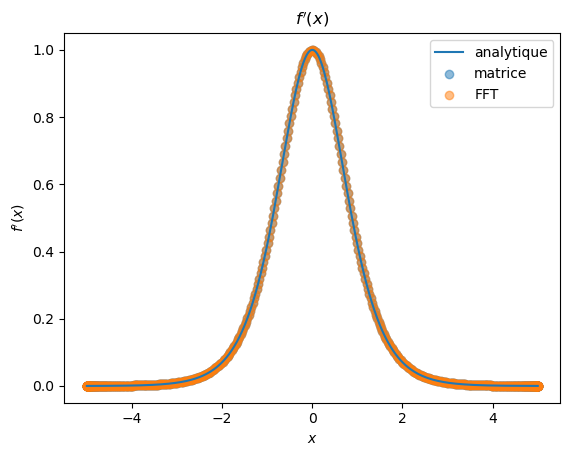

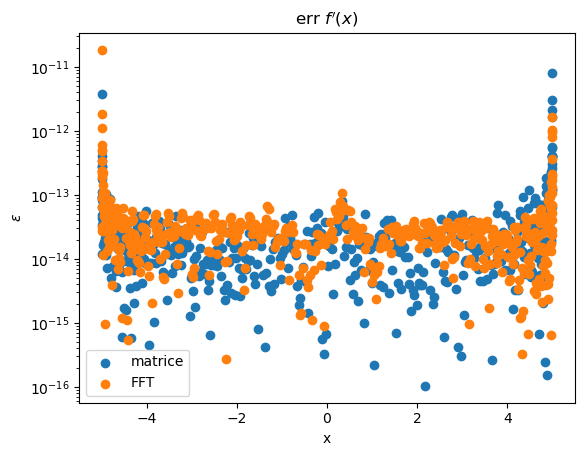

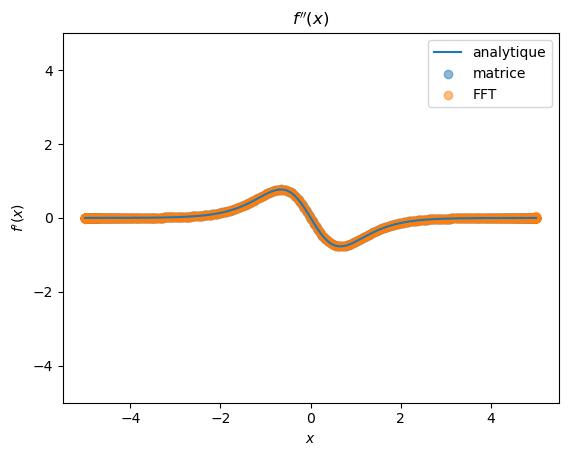

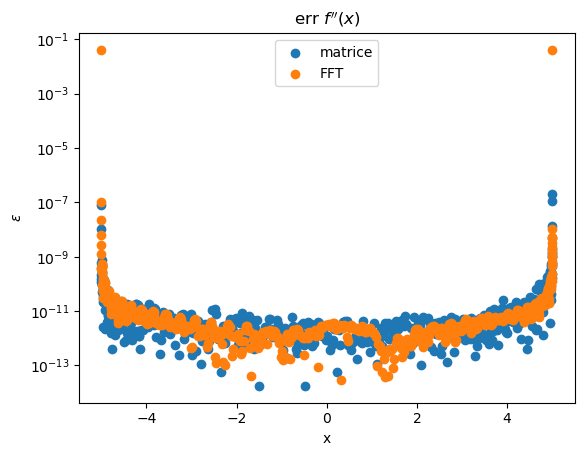

In [6]:
#Petit test sur la fonction tanh

f = lambda X : np.tanh(X)
#f = lambda X : np.exp(X)
f_prime = lambda X : 1./np.cosh(X)**2
f_pprime = lambda X : -2.*np.tanh(X)/(np.cosh(X)**2)

N=512

A =-5.0
B = 5.0

D= Cheb_diff(N, a= A, b= B)
x = collocation_points(N, a= A, b= B)

D2 = D@D

f_p_mat = D@f(x)
f_pp_mat =  D2@f(x)

f_p_FFT = Cheb_FFT(f(x), a= A, b=B)

f_pp_FFT = Cheb_second_FFT(f(x), a= A, b=B)
#f_pp_FFT = Cheb_FFT(Cheb_FFT(f(x), a= A, b =B), a=A, b=B)
fig = plt.figure()
plt.title(r"$f'(x)$")
plt.plot(x, f_prime(x), label = "analytique")
plt.scatter(x, f_p_mat, label = 'matrice', alpha = 0.5)
plt.scatter(x, f_p_FFT, label = 'FFT', alpha = 0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$f'(x)$")
plt.legend()

err_mat = np.abs(f_prime(x) - f_p_mat)
err_FFT = np.abs(f_prime(x) - f_p_FFT)

fig = plt.figure()
plt.title(r"err $f'(x)$")
plt.scatter(x, err_mat, label='matrice')
plt.scatter(x, err_FFT, label = 'FFT')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")
plt.yscale("log")
plt.legend()


fig = plt.figure()
plt.title(r"$f''(x)$")
plt.plot(x, f_pprime(x), label = "analytique")
plt.scatter(x, f_pp_mat, label = 'matrice', alpha = 0.5)
plt.scatter(x, f_pp_FFT, label = 'FFT', alpha = 0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$f'(x)$")
plt.legend()
plt.ylim(-5., 5.)

err_mat2 = np.abs(f_pprime(x) - f_pp_mat)
err_FFT2 = np.abs(f_pprime(x) - f_pp_FFT)

fig = plt.figure()
plt.title(r"err $f''(x)$")
plt.scatter(x, err_mat2, label='matrice')
plt.scatter(x, err_FFT2, label = 'FFT')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")
plt.yscale("log")
plt.legend()

In [7]:
#Matrice de dérivée du 2e ordre avec prise en compte des BCs de Dirichlet/Neumann/Robin
#De la forme u(i)+d(u(i)), i = 0, N. Il faut que ce soit d'un meme type
def Cheb2_BC(N, a=-1.0, b=1.0, BC_xm1 = 'Dirichlet', BC_xp1 = 'Dirichlet', get_D = False):
    """
    Matrice de dérivée du 2e ordre avec prise en compte des BCs de Dirichlet/Neumann
    De la forme u(i)+d(u(i)), i = 0, N.
    Valeurs possibles de BC_xm1 (CL en -1 ou en a) et BC_xp1 (CL en 1 ou en b) : 'Dirichlet', 'Neumann', 'Robin'. 
    SANS GARANTIE POUR ROBIN !!!
    """
    D = Cheb_diff(N, a=a, b=b)
    D2 = D@D
    
    if BC_xm1 == 'Dirichlet':
        D2[0, 0] = 1.0
        D2[0, 1:] = 0.0
        D[0, 0] = 1.0
        D[0, 1:] = 0.0
    
    elif BC_xm1 == 'Neumann':
        D2[0, :] = D[0, :].copy()
    
    elif BC_xm1 == 'Robin':
        D2[0, :] = D[0, :]
        D2[0, 0] +=1.0
        D[0, 0] = 1.0
        D[0, 1:-1] = 0.0
    else:
        raise ValueError(f"BC_xm1 must be in ('Dirichlet', 'Neumann', 'Robin'), current value '{BC_xm1}'")

    if BC_xp1 == 'Dirichlet':
        D2[-1, -1] = 1.0
        D2[-1, 0:-1] = 0.0
        D[-1, -1] = 1.0
        D[-1, 0:-1] = 0.0
    
    elif BC_xp1 == 'Neumann':
        D2[-1, :] = D[-1, :].copy()
    
    elif BC_xp1 == 'Robin':
        D2[-1, :] = D[-1, :].copy()
        D2[-1, -1] +=1.0
        D[-1, 0:-1] = 0.0
        D[-1, -1] = 1.0
    else:
        raise ValueError(f"BC_xp1 must be in ('Dirichlet', 'Neumann', 'Robin'), current value '{BC_xp1}'")
    if get_D:
        return D, D2
    return D2

D, D2=Cheb2_BC(8,BC_xm1 = 'Dirichlet', BC_xp1 = 'Dirichlet', get_D =  True)
print(f"Test Dirichlet")
print(f"D = {D}")
print(f"D2 = {D2}")

D, D2=Cheb2_BC(8,BC_xm1 = 'Neumann', BC_xp1 = 'Neumann', get_D =  True)
print(f"Test Neumann")
print(f"D = {D}")
print(f"D2 = {D2}")

D, D2=Cheb2_BC(8,BC_xm1 = 'Robin', BC_xp1 = 'Robin', get_D =  True)
print(f"Test Robin")
print(f"D = {D}")
print(f"D2 = {D2}")

Test Dirichlet
D = [[ 1.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 5.04891734 -2.39294678 -3.60387547  1.47395246 -0.89008374  0.65597056
  -0.55495813  0.26302377]
 [-1.32798528  3.60387547 -0.51000337 -2.49395921  1.1820181  -0.80193774
   0.65597056 -0.30797853]
 [ 0.64310413 -1.47395246  2.49395921 -0.11705659 -2.2469796   1.1820181
  -0.89008374  0.40899095]
 [-0.40899095  0.89008374 -1.1820181   2.2469796   0.11705659 -2.49395921
   1.47395246 -0.64310413]
 [ 0.30797853 -0.65597056  0.80193774 -1.1820181   2.49395921  0.51000337
  -3.60387547  1.32798528]
 [-0.26302377  0.55495813 -0.65597056  0.89008374 -1.47395246  3.60387547
   2.39294678 -5.04891734]
 [ 0.          0.          0.          0.          0.          0.
   0.          1.        ]]
D2 = [[   1.            0.            0.            0.            0.
     0.            0.            0.        ]
 [  77.80268418 -113.20777613   43.22360127  -11.39925129    5.84434414
   

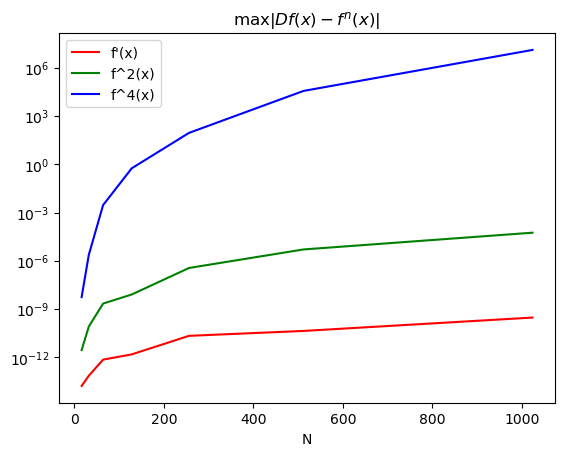

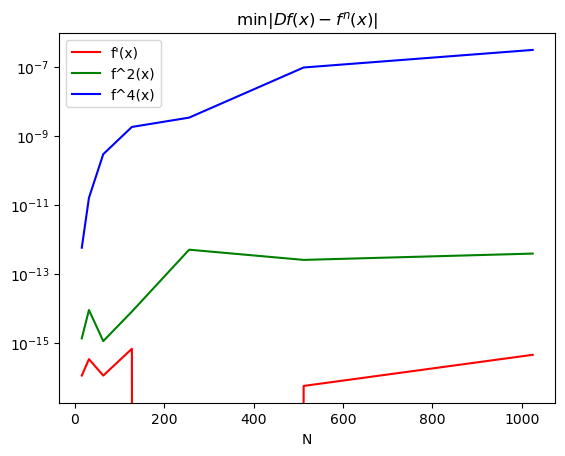

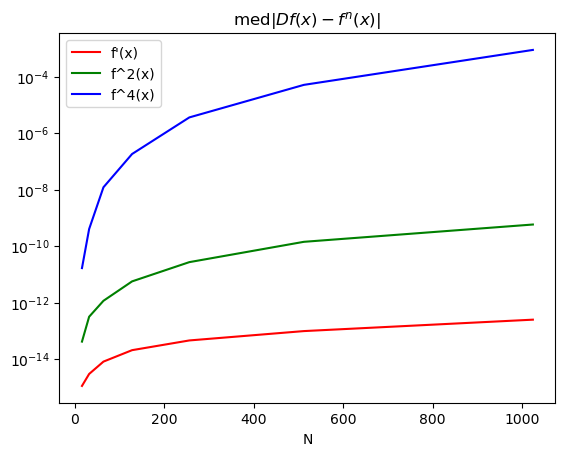

In [8]:
#Convergence de la matrice de différenciation

liste_N = np.array([16, 32, 64, 128, 256, 512, 1024])

f_ana = lambda xx:np.cosh(xx)
fp_ana = lambda xx:np.sinh(xx)
f2_ana = lambda xx:np.cosh(xx)
f4_ana = lambda xx: np.cosh(xx)

liste_err_min_1 = np.zeros(len(liste_N))
liste_err_max_1 = np.zeros(len(liste_N))
liste_err_med_1 = np.zeros(len(liste_N))


liste_err_min_2 = np.zeros(len(liste_N))
liste_err_max_2 = np.zeros(len(liste_N))
liste_err_med_2 = np.zeros(len(liste_N))

liste_err_min_4 = np.zeros(len(liste_N))
liste_err_max_4 = np.zeros(len(liste_N))
liste_err_med_4 = np.zeros(len(liste_N))

for i in range(0, len(liste_N)):
    x_i = collocation_points(liste_N[i])
    D_i = Cheb_diff(liste_N[i])
    D2_i = D_i @ D_i
    D4_i = D2_i@D2_i
    err_1 = np.abs(fp_ana(x_i) - D_i@f_ana(x_i))
    err_2 = np.abs(f2_ana(x_i) - D2_i@f_ana(x_i))
    err_4 = np.abs(f4_ana(x_i) - D4_i@f_ana(x_i))

    liste_err_max_1[i] = err_1.max()
    liste_err_max_2[i] = err_2.max()
    liste_err_max_4[i] = err_4.max()

    liste_err_min_1[i] = err_1.min()
    liste_err_min_2[i] = err_2.min()
    liste_err_min_4[i] = err_4.min()

    liste_err_med_1[i] = np.median(err_1)
    liste_err_med_2[i] = np.median(err_2)
    liste_err_med_4[i] = np.median(err_4)


fig = plt.figure()
plt.title(r"$\max|D f(x) - f^n(x)|$")
plt.plot(liste_N, liste_err_max_1, label = "f'(x)", color = 'r')
plt.plot(liste_N, liste_err_max_2, label = "f^2(x)", color = 'g')
plt.plot(liste_N, liste_err_max_4, label = "f^4(x)", color = 'b')
plt.xlabel('N')
plt.yscale('log')
plt.legend()

fig = plt.figure()
plt.title(r"$\min|D f(x) - f^n(x)|$")
plt.plot(liste_N, liste_err_min_1, label = "f'(x)", color = 'r')
plt.plot(liste_N, liste_err_min_2, label = "f^2(x)", color = 'g')
plt.plot(liste_N, liste_err_min_4, label = "f^4(x)", color = 'b')
plt.xlabel('N')
plt.yscale('log')
plt.legend()

fig = plt.figure()
plt.title(r"$\mathrm{med}|D f(x) - f^n(x)|$")
plt.plot(liste_N, liste_err_med_1, label = "f'(x)", color = 'r')
plt.plot(liste_N, liste_err_med_2, label = "f^2(x)", color = 'g')
plt.plot(liste_N, liste_err_med_4, label = "f^4(x)", color = 'b')
plt.xlabel('N')
plt.yscale('log')
plt.legend()

# Adaptation de certaines fonctions de la librairie MATLAB écrites par Weideman
## Calcul de la dérivée d'ordre $n$ par FFT (`chebdifft`)

x = [ 1.          0.9999811   0.99992441  0.99982992  0.99969764  0.99952757
  0.99931973  0.99907412  0.99879074  0.99846961  0.99811074  0.99771415
  0.99727985  0.99680785  0.99629817  0.99575084  0.99516588  0.9945433
  0.99388312  0.99318539  0.99245011  0.99167732  0.99086705  0.99001933
  0.98913418  0.98821165  0.98725177  0.98625458  0.98522011  0.9841484
  0.98303949  0.98189342  0.98071025  0.97949     0.97823273  0.97693849
  0.97560733  0.97423929  0.97283442  0.97139279  0.96991444  0.96839943
  0.96684781  0.96525966  0.96363502  0.96197395  0.96027653  0.95854281
  0.95677287  0.95496675  0.95312455  0.95124632  0.94933213  0.94738207
  0.94539619  0.94337458  0.94131732  0.93922447  0.93709613  0.93493237
  0.93273327  0.93049891  0.92822939  0.92592478  0.92358517  0.92121066
  0.91880132  0.91635726  0.91387856  0.91136532  0.90881764  0.9062356
  0.90361931  0.90096887  0.89828437  0.89556592  0.89281362  0.89002758
  0.88720789  0.88435467  0.88146803  0.87854807  

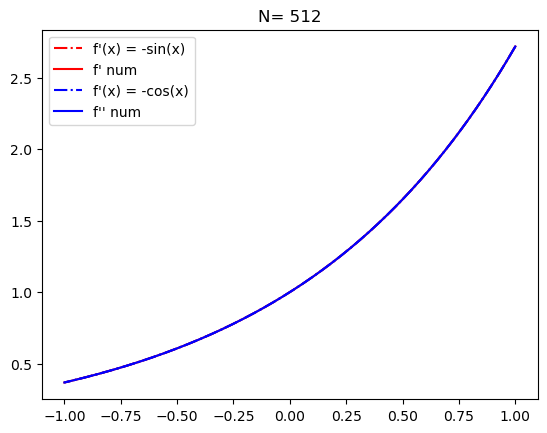

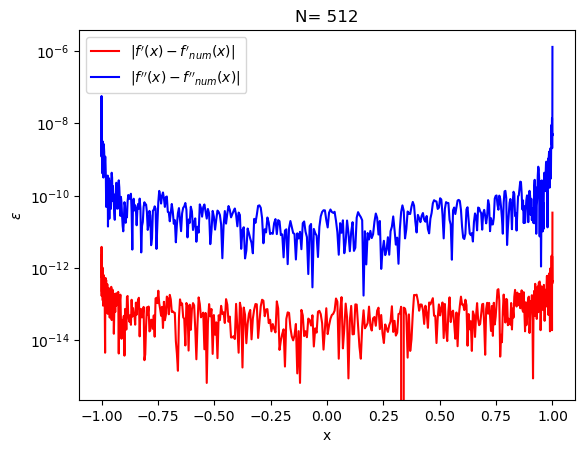

In [9]:
def print_arr2D(a):
    if len(a.shape) == 1 : 
        str_i = '['
        for i in range(0, a.shape[0]):
            str_i += f" {a[i]},\n" if np.abs(a[i]) >1.0e-15 else " 0.,\n"
        print(str_i+']')
    else:
        print("[")
        for i in range(0, a.shape[0]):
            str_i = '['
            for j in range(0, a.shape[1]):
                str_j=f" {a[i, j]}," if np.abs(a[i, j]) >1.0e-15 else " 0.,"
                str_i+=str_j
            print(str_i+"]")
        print("]")

debug = True
def Cheb_diff_FFT(f, n=1):
    # f : vecteur 1D de taille > 4
    N = f.size
    if debug:
        print(f"N = {N}")
        print("f = ");print_arr2D(f)
        print(f"np.concatenate([f, np.flipud(f[1:N-1])])"); print_arr2D(np.concatenate([f, np.flipud(f[1:N-1])]))
        
    a0 = scipy.fft.fft( np.concatenate( [f, np.flipud(f[1:N-1]) ] ) )

    if debug:
        print(f"a0 = "); print_arr2D(a0)
        print(f"a0[0:N] = "); print_arr2D(a0[0:N])
        print(np.ones(N-2))
    #coeff_a = np.ravel(np.concatenate([[0.5], np.ones(N-2), [0.5]], dtype = 'complex'))
    coeff_a = np.r_[[0.5], np.ones(N-2), [0.5]]
    #coeff_a = np.vstack(coeff_a)
    if debug:
        print("coeff_a = ");print_arr2D(coeff_a)
    
    a0_mat = a0[0:N]*coeff_a/(N-1)
    
    if debug:
        print("a0_mat =")
        print_arr2D(a0_mat)
        print([a0_mat, np.zeros((N, n))])
        
    a = np.concatenate([np.vstack(a0_mat), np.zeros((N, n), dtype = 'complex')], axis = 1)

    if debug:
        print("a = ")
        print_arr2D(a)
        print("Debut boucle")

    for i in range(1, n+1) : 

        if debug:
            print(f"i = {i}")
            print(f"N-i-1 = {N-i-1}, i = {i}")
        
        a[N-i, i+1] = 2.0*(N-i)*a[N-i+1, i]
        
        if debug:
            print(f"a[N-i-1, i] = {a[N-i-1, i]}")
            
        for k in range(N-i-2, 0, -1):

            if debug:
                print(f"k = {k}")
            
            a[k+1, i+1] = a[k+3, i+1] + 2.0 * (k+1) * a[k+1, i]

            if debug:
                print(f"a[k+1, i-1] {a[k+1, i-1]}")
                #print(f"a[k+2, i-1] = {a[k+2, i-1]}")
                print(f"a[k, i] = {a[k, i]}")

        if debug:
            print(f"a=");print_arr2D(a)
            
        a[1, i+1] = a[2, i] + ( a[3, i+1] / 2.0 )
        if debug:
            print(f"a[0, i] = {a[0, i]}")
            print("a = ");print_arr2D(a)
    
    if debug:
        print("fin boucle")
        print("a=")
        print_arr2D(a)
        print(f"a[0, n] = {a[0, n]}")
        print(f"a[1:N-1, n] = {a[1:N-1, n]}")
        print(f"np.flipud(a[1:N-1,n]) = {np.flipud(a[1:N-1,n])}")

    
    #back = np.concatenate([2.0*a[0, n], a[1:N-1, n], np.flipud(a[1:N-1,n])])
    back = np.r_[2.0*a[0, n], a[1:N-1, n], 2.0*a[N-1, n], np.flipud(a[1:N-1,n])]

    if debug:
        print(f"back =");print_arr2D(back)
    
    Dmf = 0.5*scipy.fft.fft(back)[0:N]

    if debug:
        print(f"Dmf = ");print_arr2D(Dmf)
        
    return Dmf.real

def chebdifft_matlab_emulated(f, M=1, inf_bound=-1.0, sup_bound=1.0):
    """
    Emulation 1:1 du code MATLAB en utilisant un dictionnaire ou des indices 
    décalés pour éviter toute erreur de traduction de boucle.
    On crée des tableaux de taille (N+1) ou (N+1, M+2) pour utiliser directement
    les indices MATLAB (1 à N) et (1 à M+1).
    """
    f = np.asarray(f, dtype=complex).flatten()
    N = len(f)
    
    # En MATLAB: f=f(:); a0=fft([f; flipud(f(2:N-1))]);
    # f(2:N-1) en MATLAB correspond aux indices 2 à N-1 inclus.
    # En Python (index-0), cela correspond à f[1:N-1]
    f_flip = f[1:N-1][::-1]
    f_ext = np.concatenate([f, f_flip])
    a0_fft = np.fft.fft(f_ext)
    
    # En MATLAB: a0=a0(1:N).*[0.5; ones(N-2,1); 0.5]/(N-1);
    # On crée un tableau indexé de 1 à N pour coller au MATLAB
    a0_matlab = np.zeros(N + 1, dtype=complex)
    weights = np.ones(N)
    weights[0] = 0.5
    weights[-1] = 0.5
    a0_matlab[1:N+1] = a0_fft[:N] * weights / (N - 1)
    
    # En MATLAB: a=[a0 zeros(N,M)];
    # Taille MATLAB : N lignes, M+1 colonnes.
    # On crée une matrice de taille (N+1) x (M+2) pour utiliser les indices 1..N et 1..M+1
    a = np.zeros((N + 1, M + 2), dtype=complex)
    a[1:N+1, 1] = a0_matlab[1:N+1]

    # Boucle MATLAB exacte
    for ell in range(1, M + 1):
        # a(N-ell,ell+1)=2*(N-ell)*a(N-ell+1,ell);
        a[N - ell, ell + 1] = 2 * (N - ell) * a[N - ell + 1, ell]
        
        # for k=N-ell-2:-1:1
        for k in range(N - ell - 2, 0, -1):
            # a(k+1,ell+1)=a(k+3,ell+1)+2*(k+1)*a(k+2,ell);
            a[k + 1, ell + 1] = a[k + 3, ell + 1] + 2 * (k + 1) * a[k + 2, ell]
            
        # a(1,ell+1)=a(2,ell)+a(3,ell+1)/2;
        a[1, ell + 1] = a[2, ell] + a[3, ell + 1] / 2.0

    # back=[2*a(1,M+1); a(2:N-1,M+1); 2*a(N,M+1); flipud(a(2:N-1,M+1))];
    # Construction du vecteur 'back' en suivant scrupuleusement les indices MATLAB
    # a(2:N-1, M+1) signifie de la ligne 2 à N-1 incluse
    part2 = a[2:N, M + 1]
    part4 = part2[::-1] # flipud
    
    back = np.concatenate([
        [2 * a[1, M + 1]],
        part2,
        [2 * a[N, M + 1]],
        part4
    ])
    
    # Dmf=0.5*fft(back); Dmf=Dmf(1:N);
    Dmf = 0.5 * np.fft.fft(back)
    Dmf = Dmf[:N]
    
    coeff_domaine = (2.0/(sup_bound-inf_bound))**M
    #print(f"coeff_domaine {coeff_domaine}")
    return coeff_domaine * (Dmf.real)
    
Nx =512
x = collocation_points(Nx)
print(f"x = {x}")
#f_x = np.cos(x)
#fp_x = -np.sin(x)
#fpp_x = -np.cos(x)

f_x = np.exp(x)
fp_x = np.exp(x)
fpp_x = np.exp(x)

print("################Calcul dérivée première################")
#fp_num = Cheb_diff_FFT(f_x)
fp_num =chebdifft_matlab_emulated(f_x, 1)


print("###############################################")
print("###############################################")
print("################Calcul dérivée seconde################")

#fpp_num = Cheb_diff_FFT(f_x, 2)
fpp_num = chebdifft_matlab_emulated(f_x, 2)

print("###############################################")
err_1 = np.abs(fp_x - fp_num)
err_2 = np.abs(fpp_num - fpp_x)

print(f"fp_x = {fp_x}")
print(f"fp_num = {fp_num}")
print(f"err_1 = {err_1}")
print(f"err_2 = {err_2}")

fig = plt.figure()
plt.title(f"N= {Nx}")
plt.plot(x, fp_x, label = "f'(x) = -sin(x)", linestyle = '-.', color = 'r')
plt.plot(x, fp_num, label = "f' num", color = 'r')

plt.plot(x, fpp_x, label = "f'(x) = -cos(x)", linestyle = '-.', color = 'b')
plt.plot(x, fpp_num, label = "f'' num", color = 'b')

plt.legend()

fig = plt.figure()
plt.title(f"N= {Nx}")
plt.plot(x, err_1, label = r"$|f'(x) - f'_{num}(x)|$", color = 'r')
plt.plot(x, err_2, label = r"$|f''(x) - f''_{num}(x)|$", color = 'b')
plt.xlabel("x")
plt.ylabel(r"$\epsilon$")
plt.yscale('log')
plt.legend()

Tests de convergence

In [10]:
import matplotlib.colors as mcolors
mcolors.BASE_COLORS

{'b': (0, 0, 1),
 'g': (0, 0.5, 0),
 'r': (1, 0, 0),
 'c': (0, 0.75, 0.75),
 'm': (0.75, 0, 0.75),
 'y': (0.75, 0.75, 0),
 'k': (0, 0, 0),
 'w': (1, 1, 1)}

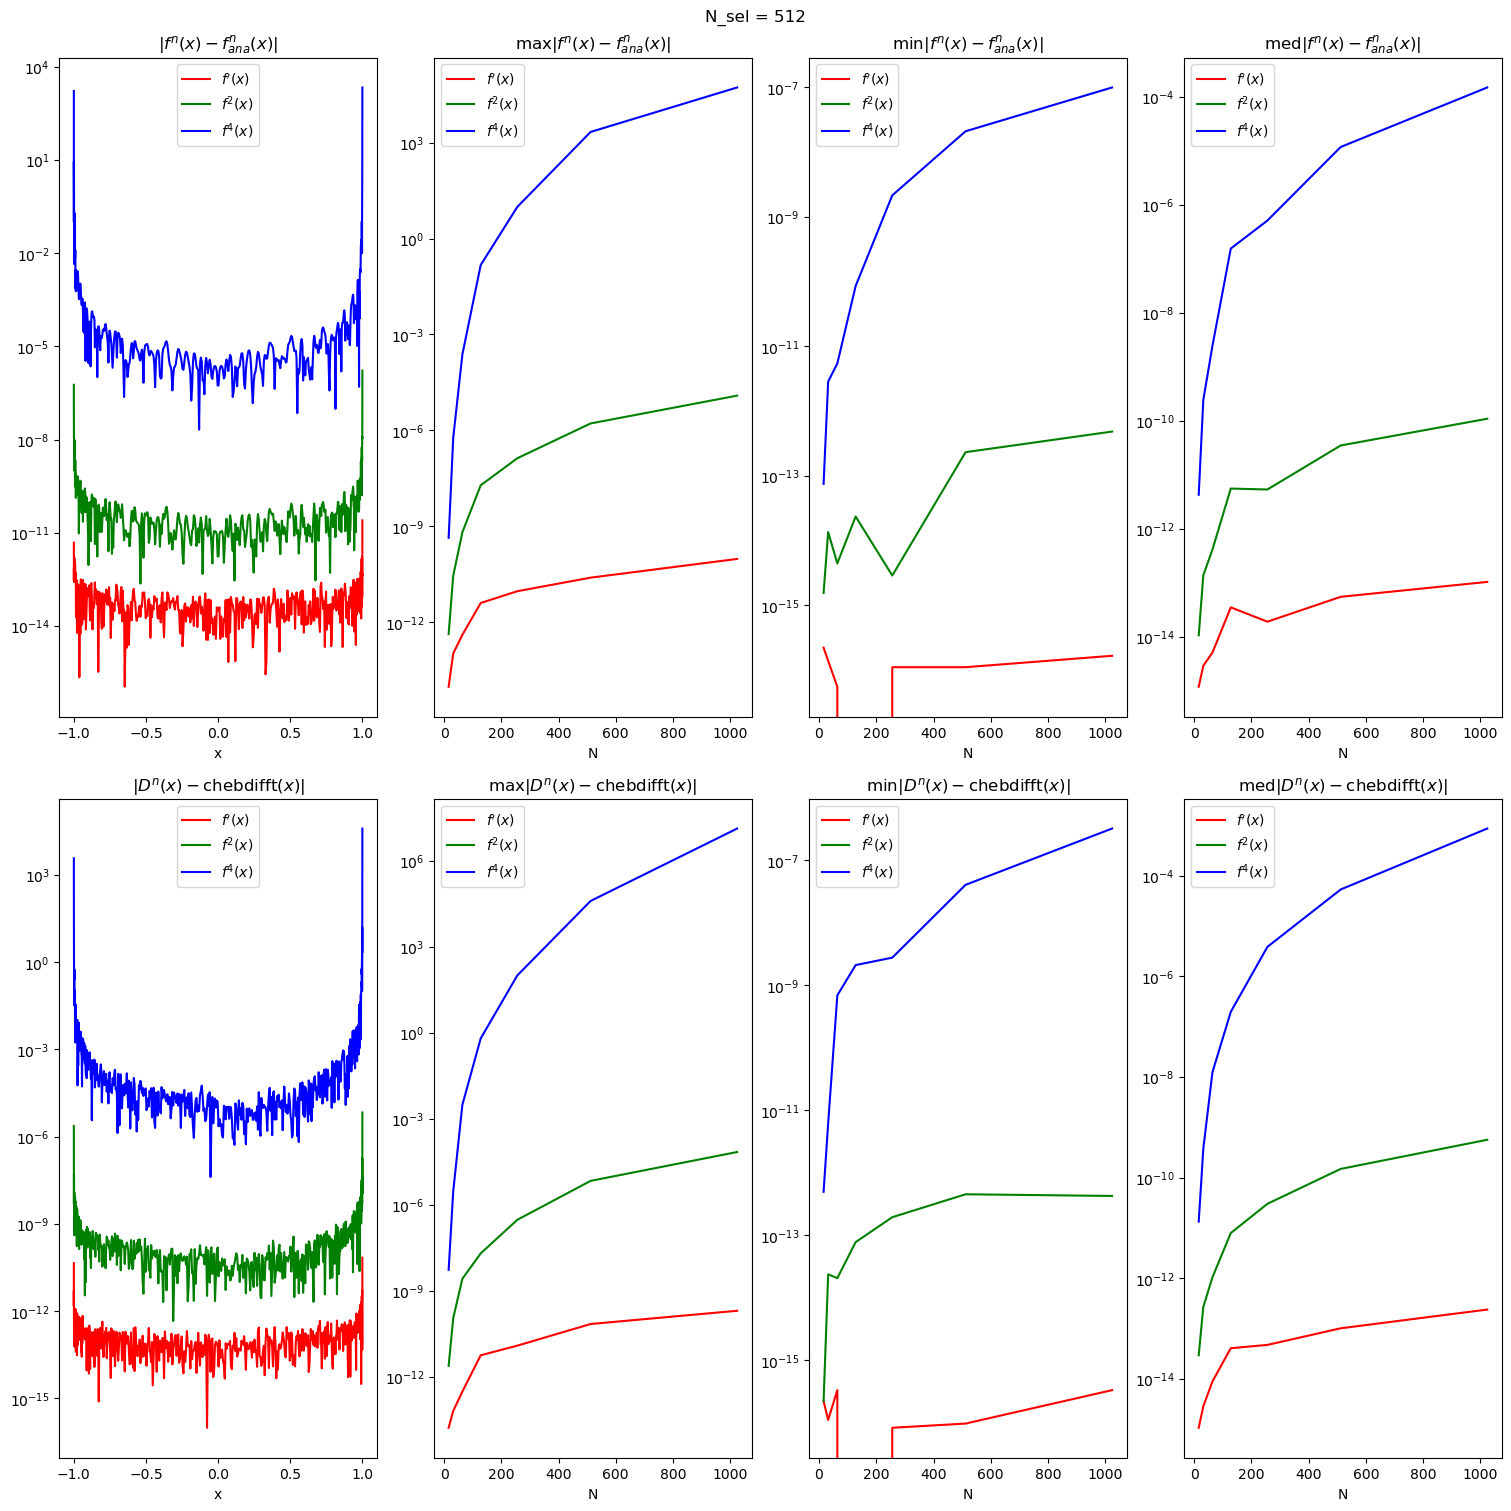

In [11]:
liste_N = np.array([16, 32, 64, 128, 256, 512, 1024])
liste_err_max_1 = np.zeros(len(liste_N))
liste_err_max_2 = np.zeros(len(liste_N))
liste_err_max_4 = np.zeros(len(liste_N))

liste_err_max_1D = np.zeros(len(liste_N))
liste_err_max_2D = np.zeros(len(liste_N))
liste_err_max_4D = np.zeros(len(liste_N))




liste_err_min_1 = np.zeros(len(liste_N))
liste_err_min_2 = np.zeros(len(liste_N))
liste_err_min_4 = np.zeros(len(liste_N))

liste_err_min_1D = np.zeros(len(liste_N))
liste_err_min_2D = np.zeros(len(liste_N))
liste_err_min_4D = np.zeros(len(liste_N))



liste_err_med_1 = np.zeros(len(liste_N))
liste_err_med_2 = np.zeros(len(liste_N))
liste_err_med_4 = np.zeros(len(liste_N))


liste_err_med_1D = np.zeros(len(liste_N))
liste_err_med_2D = np.zeros(len(liste_N))
liste_err_med_4D = np.zeros(len(liste_N))



f_ana = lambda xx:np.cosh(xx)
fp_ana = lambda xx : np.sinh(xx)
fpp_ana = lambda xx : np.cosh(xx)
f4_ana = lambda xx : np.cosh(xx)

fig = plt.figure( figsize  = (15, 15), constrained_layout = True)
axs = fig.subplots(2, 4, squeeze = False, sharex = False, sharey = False)

liste_c = ['r', 'g', 'b']

N_sel = 512

if N_sel not in liste_N : 
    raise ValueError(f"N={N} doit etre dans liste_N; Valeurs possibles  {liste_N}")

x_N_sel = collocation_points(N_sel)
#print(x_N_sel)
f_x_N_sel = f_ana(x_N_sel)
D_N = Cheb_diff(N_sel)

D2_N = D_N@D_N
D4_N = D2_N@D2_N

fp_num = chebdifft_matlab_emulated(f_x_N_sel, 1)
fpp_num = chebdifft_matlab_emulated(f_x_N_sel, 2)
f4_num = chebdifft_matlab_emulated(f_x_N_sel, 4)



err_1 = np.abs(fp_num - fp_ana(x_N_sel) )
err_2 = np.abs(fpp_num - fpp_ana(x_N_sel) )
err_4 = np.abs(f4_num - f4_ana(x_N_sel) )

err_1D = np.abs(fp_num - (D_N @ f_x_N_sel) )
err_2D = np.abs(fpp_num - (D2_N @ f_x_N_sel) )
err_4D = np.abs(f4_num - (D4_N @ f_x_N_sel) )



fig.suptitle(f"N_sel = {N_sel}")
#axs[0, 0].plot(n, err_pol)

axs[0, 0].set_title(r'$|f^n(x) - f^n_{ana}(x)|$')
axs[0, 0].plot(x_N_sel, err_1, label = r"$f'(x)$", color = 'r')
axs[0, 0].plot(x_N_sel, err_2, label = r"$f^2(x)$", color = 'g')
axs[0, 0].plot(x_N_sel, err_4, label = r"$f^4(x)$", color = 'b')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_yscale('log')
axs[0, 0].legend()




#axs[1, 0].plot(n, err_sm)
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r"$|D^n(x) - \mathrm{chebdifft}(x)|$")
axs[1, 0].plot(x_N_sel, err_1D, label = r"$f'(x)$", color = 'r')
axs[1, 0].plot(x_N_sel, err_2D, label = r"$f^2(x)$", color = 'g')
axs[1, 0].plot(x_N_sel, err_4D, label = r"$f^4(x)$", color = 'b')
axs[1, 0].legend()
axs[1, 0].set_xlabel('x')


for i in range(0, len(liste_N)):
    x_i = collocation_points(liste_N[i])
    D_i = Cheb_diff(liste_N[i])
    D2_i = D_i @ D_i
    D4_i = D2_i @ D2_i

    f_x_i = f_ana(x_i)

    fp_FFT_i = chebdifft_matlab_emulated(f_x_i, 1)
    fpp_FFT_i = chebdifft_matlab_emulated(f_x_i, 2)
    f4_FFT_i = chebdifft_matlab_emulated(f_x_i, 4)
    err_1 = np.abs(fp_FFT_i - fp_ana(x_i) )
    err_2 = np.abs(fpp_FFT_i - fpp_ana(x_i) )
    err_4 = np.abs(f4_FFT_i - f4_ana(x_i) )

    
    liste_err_max_1[i] = err_1.max()
    liste_err_max_2[i] = err_2.max()
    liste_err_max_4[i] = err_4.max()

    liste_err_min_1[i] = err_1.min()
    liste_err_min_2[i] = err_2.min()
    liste_err_min_4[i] = err_4.min()

    liste_err_med_1[i] = np.median(err_1)
    liste_err_med_2[i] = np.median(err_2)
    liste_err_med_4[i] = np.median(err_4)
    
    err_1D = np.abs(fp_FFT_i - (D_i @ f_x_i) )
    err_2D = np.abs(fpp_FFT_i - (D2_i @ f_x_i))
    err_4D = np.abs(f4_FFT_i - (D4_i @ f_x_i))
    
    liste_err_max_1D[i] = err_1D.max()
    liste_err_max_2D[i] = err_2D.max()
    liste_err_max_4D[i] = err_4D.max()

    liste_err_min_1D[i] = err_1D.min()
    liste_err_min_2D[i] = err_2D.min()
    liste_err_min_4D[i] = err_4D.min()

    liste_err_med_1D[i] = np.median(err_1D)
    liste_err_med_2D[i] = np.median(err_2D)
    liste_err_med_4D[i] = np.median(err_4D)

axs[0, 1].set_title(r'$\max|f^n(x) - f^n_{ana}(x)|$')
axs[0, 1].plot(liste_N, liste_err_max_1, label = r"$f'(x)$", color = 'r')
axs[0, 1].plot(liste_N, liste_err_max_2, label = r"$f^2(x)$", color = 'g')
axs[0, 1].plot(liste_N, liste_err_max_4, label = r"$f^4(x)$", color = 'b')
axs[0, 1].set_yscale('log')
axs[0, 1].set_xlabel('N')
axs[0, 1].legend()


axs[0, 2].set_title(r'$\min|f^n(x) - f^n_{ana}(x)|$')
axs[0, 2].plot(liste_N, liste_err_min_1, label = r"$f'(x)$", color = 'r')
axs[0, 2].plot(liste_N, liste_err_min_2, label = r"$f^2(x)$", color = 'g')
axs[0, 2].plot(liste_N, liste_err_min_4, label = r"$f^4(x)$", color = 'b')
axs[0, 2].set_yscale('log')
axs[0, 2].set_xlabel('N')
axs[0, 2].legend()


axs[0, 3].set_title(r'$\mathrm{med}|f^n(x) - f^n_{ana}(x)|$')
axs[0, 3].plot(liste_N, liste_err_med_1, label = r"$f'(x)$", color = 'r')
axs[0, 3].plot(liste_N, liste_err_med_2, label = r"$f^2(x)$", color = 'g')
axs[0, 3].plot(liste_N, liste_err_med_4, label = r"$f^4(x)$", color = 'b')
axs[0, 3].set_yscale('log')
axs[0, 3].set_xlabel('N')
axs[0, 3].legend()



axs[1, 1].set_title(r"$\max|D^n(x) - \mathrm{chebdifft}(x)|$")
axs[1, 1].plot(liste_N, liste_err_max_1D, label = r"$f'(x)$", color = 'r')
axs[1, 1].plot(liste_N, liste_err_max_2D, label = r"$f^2(x)$", color = 'g')
axs[1, 1].plot(liste_N, liste_err_max_4D, label = r"$f^4(x)$", color = 'b')
axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel('N')
axs[1, 1].legend()

axs[1, 2].set_title(r"$\min|D^n(x) - \mathrm{chebdifft}(x)|$")
axs[1, 2].plot(liste_N, liste_err_min_1D, label = r"$f'(x)$", color = 'r')
axs[1, 2].plot(liste_N, liste_err_min_2D, label = r"$f^2(x)$", color = 'g')
axs[1, 2].plot(liste_N, liste_err_min_4D, label = r"$f^4(x)$", color = 'b')
axs[1, 2].set_yscale('log')
axs[1, 2].set_xlabel('N')
axs[1, 2].legend()


axs[1, 3].set_title(r"$\mathrm{med}|D^n(x) - \mathrm{chebdifft}(x)|$")
axs[1, 3].plot(liste_N, liste_err_med_1D, label = r"$f'(x)$", color = 'r')
axs[1, 3].plot(liste_N, liste_err_med_2D, label = r"$f^2(x)$", color = 'g')
axs[1, 3].plot(liste_N, liste_err_med_4D, label = r"$f^4(x)$", color = 'b')
axs[1, 3].set_yscale('log')
axs[1, 3].set_xlabel('N')
axs[1, 3].legend()



In [12]:
%timeit chebdifft_matlab_emulated(f_x_N_sel, 1)

493 μs ± 11.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
%timeit chebdifft_matlab_emulated(f_x_N_sel, 4)

1.44 ms ± 70.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [14]:
%timeit (lambda xx:D_N@xx)(f_x_N_sel)

33.2 μs ± 4.84 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [15]:
%timeit (lambda xx:D4_N@xx)(f_x_N_sel)

50.1 μs ± 21.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


# Test de la différenciation 2D (Chebyshev)

Pour des raisons de performance et de simplicité, j'utilise l'implémentation basée sur la FFT. 

**Attention à bien construire une grille irrégulière (points de Gauss-Lobatto). Déclarer ```x = np.linspace(-1., 1., N)```, c'est NON  (sinon malédiction sur vous pour les 30 générations à venir) !**

[[105.25278091 105.21929046 105.11881478 ... 105.11881478 105.21929046
  105.25278091]
 [105.2428755  105.20938821 105.10892199 ... 105.10892199 105.20938821
  105.2428755 ]
 [105.21316526 105.17968742 105.07924956 ... 105.07924956 105.17968742
  105.21316526]
 ...
 [105.21316526 105.17968742 105.07924956 ... 105.07924956 105.17968742
  105.21316526]
 [105.2428755  105.20938821 105.10892199 ... 105.10892199 105.20938821
  105.2428755 ]
 [105.25278091 105.21929046 105.11881478 ... 105.11881478 105.21929046
  105.25278091]]
x=0.49822766697278187
171
513
(513,)
y=6.123233995736766e-17
246


(-75.0, 75.0)

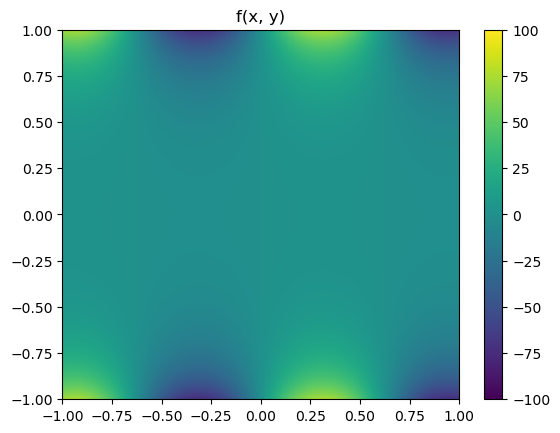

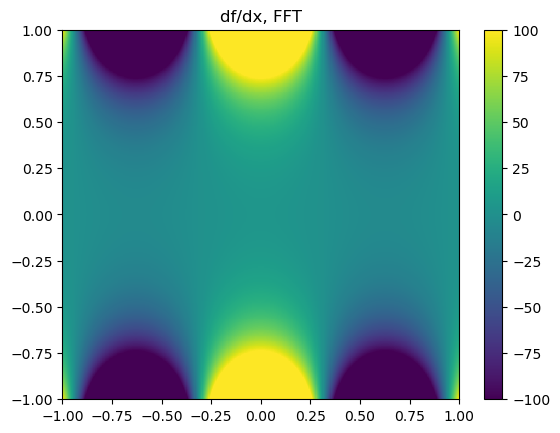

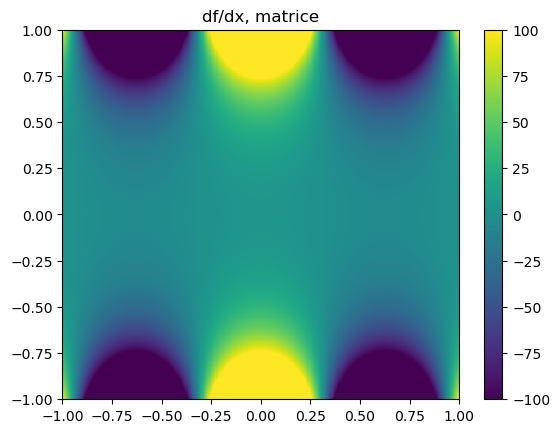

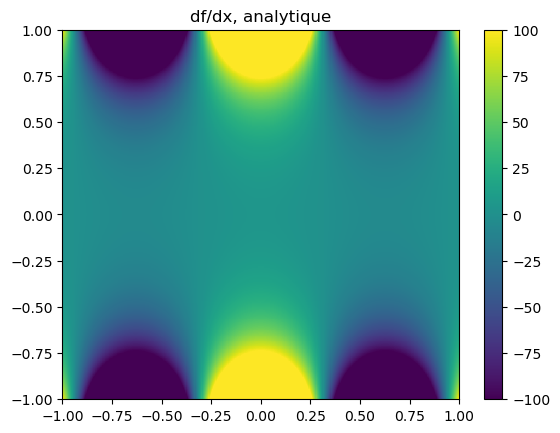

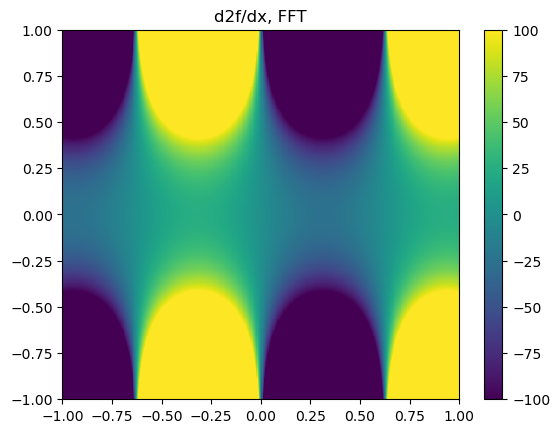

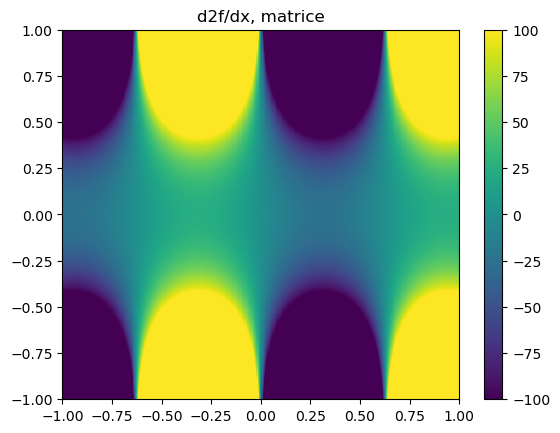

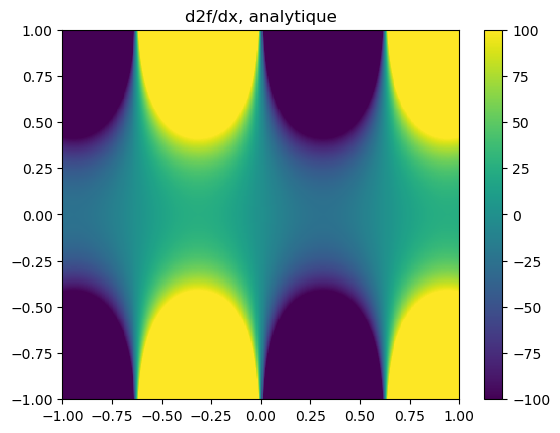

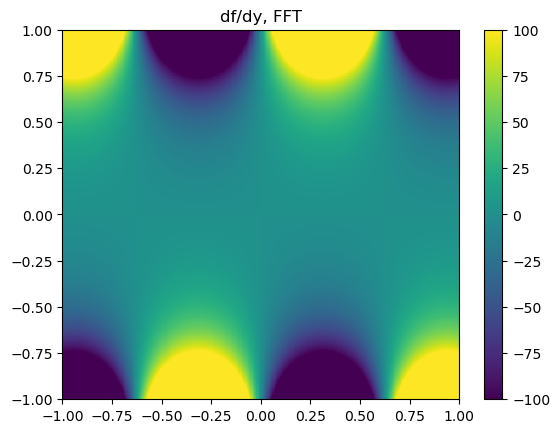

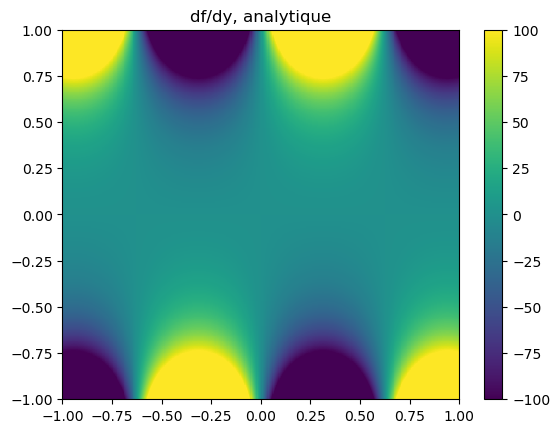

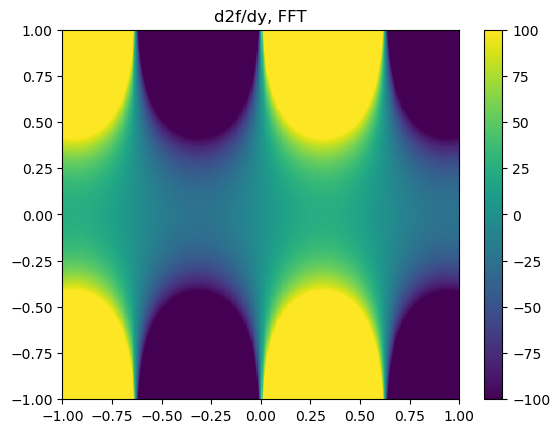

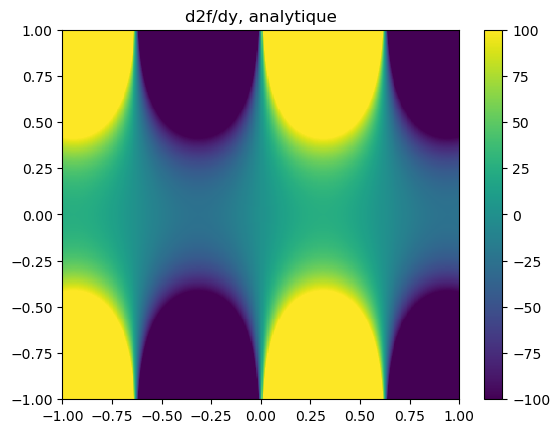

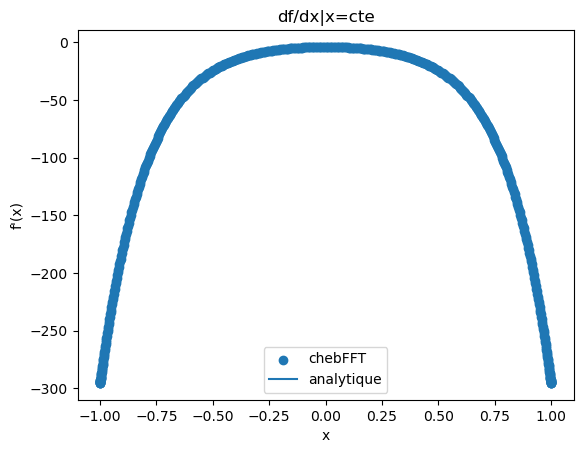

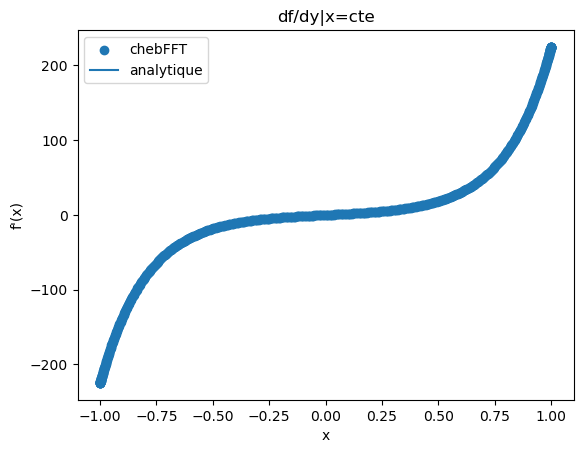

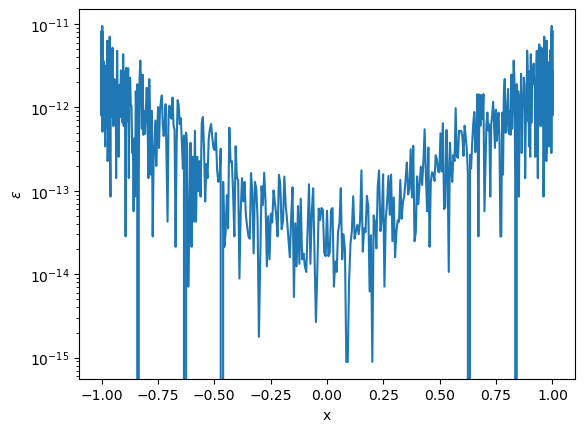

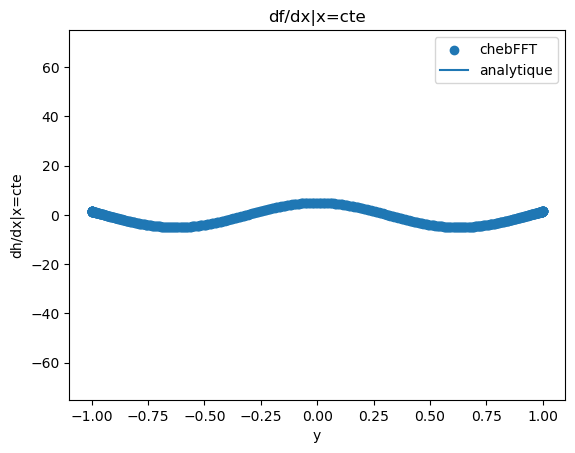

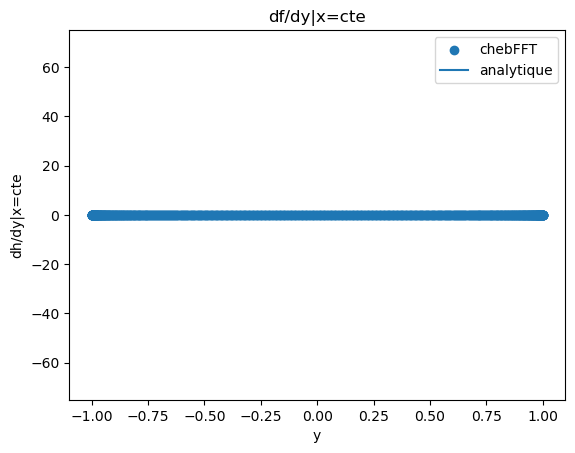

In [16]:
f = lambda x, y : np.sin(5.0*x)*np.cosh(5.0*y)

f_prime_x = lambda x, y : 5.0*np.cos(5.0*x)*np.cosh(5.0*y)
f_sec_x = lambda x, y : -25.0*f(x, y)

f_prime_y = lambda x, y : 5.0*np.sin(5.0*x)*np.sinh(5.0*y)
f_sec_y = lambda x, y : 25.0*f(x, y)

N=512
j = np.arange(N+1)
x = np.cos(np.pi * j / N)

X, Y = np.meshgrid(x, x)

f_x = f(X, Y)


def Cheb_FFT_2D(V, order = 1, axis ='x', a=-1., b= 1.):
    if order ==1 : 
        func_deriv = lambda xx : Cheb_FFT(xx, a=a, b=b)
    elif order == 2 : 
        #func_deriv = lambda xx : Cheb_second_FFT(xx, a=a, b=a)
        func_deriv = lambda xx : Cheb_FFT(Cheb_FFT(xx, a=a, b=b), a=a, b=b)
    else :
        raise ValueError
    
    if axis == 'x' or axis == 0 : 
        dVdx = np.zeros_like(V)
        for i in range(0, V.shape[0]):
            dVdx[i, :] = func_deriv(V[i, :])
        return dVdx
    elif axis == 'y' or axis == 1:
        dVdy = np.zeros_like(V)
        for i in range(0, V.shape[1]):
            dVdy[:, i] = func_deriv(V[:,i])
        return dVdy
    else:
        raise ValueError

df_dx = Cheb_FFT_2D(f_x, axis = 'x')
v_depart = np.cos(np.pi*np.arange(0, N+1)/N)
#print(v_depart)
print(df_dx)
#df_dx = Cheb_second_FFT(v_depart)
#print(df_dx)
d2f_dx = Cheb_FFT_2D(f_x, order =2, axis = 'x')


def Cheb_derivative_2D(V, order = 1, axis ='x', a = -1., b=1.):
    
    if axis == 'x' or axis == 0 : 
        dVdx = np.zeros_like(V)
        Nx = dVdx.shape[0]
        D = Cheb_diff(Nx, a=a, b=b)
        #D = D[1:-1, 1:-1]
        if order == 2 : 
            D = D@D
        for i in range(0, V.shape[1]):
            dVdx[i, :] = D@V[i, :]
        return dVdx
    elif axis == 'y' or axis == 1:
        dVdy = np.zeros_like(V)
        for i in range(0, V.shape[0]):
            dVdy[i, :] = func_deriv(V[i, :])
        return dVdy
    else:
        raise ValueError
df_dx_mat = Cheb_derivative_2D(f_x, axis = 'x')
d2f_dx_mat = Cheb_derivative_2D(f_x, order =2, axis = 'x')

f_prime_x_ana = f_prime_x(X, Y)
f_pprime_x_ana = f_sec_x(X, Y)


fig = plt.figure()
ax=plt.axes()
ax.set_title("f(x, y)")
cf = ax.pcolormesh(X, Y, f(X, Y), vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)


fig = plt.figure()
ax=plt.axes()
ax.set_title("df/dx, FFT")
cf = ax.pcolormesh(X, Y, df_dx, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dx, matrice")
cf = ax.pcolormesh(X, Y, df_dx_mat, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)

fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dx, analytique")
cf = ax.pcolormesh(X, Y, f_prime_x_ana, vmin =-100.0, vmax=100.0)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dx, FFT")
cf = ax.pcolormesh(X, Y, d2f_dx, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dx, matrice")
cf = ax.pcolormesh(X, Y, d2f_dx_mat, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("d2f/dx, analytique")
cf = ax.pcolormesh(X, Y, f_pprime_x_ana, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)




df_dy = Cheb_FFT_2D(f_x, axis = 'y')
d2f_dy = Cheb_FFT_2D(f_x, order =2, axis = 'y')

fig = plt.figure()
ax=plt.axes()
ax.set_title("df/dy, FFT")
cf = ax.pcolormesh(X, Y, df_dy, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)




fig = plt.figure()

ax=plt.axes()
ax.set_title("df/dy, analytique")
cf = ax.pcolormesh(X, Y, f_prime_y(X,Y), vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

fig = plt.figure()
ax=plt.axes()
ax.set_title("d2f/dy, FFT")
cf = ax.pcolormesh(X, Y, d2f_dy, vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

#fig = plt.figure()
#ax=plt.axes()
#ax.set_title("d2f/dy, matrice")
#cf = ax.pcolormesh(X, Y, d2f_dx_mat, vmin =-5., vmax=5.)
#fig.colorbar(cf, ax=ax)


fig = plt.figure()

ax=plt.axes()
ax.set_title("d2f/dy, analytique")
cf = ax.pcolormesh(X, Y, f_sec_y(X,Y), vmin =-100., vmax=100.)
fig.colorbar(cf, ax=ax)

y_sel = 0.5

index_y = np.abs(x -y_sel).argmin()

index = N//2-10

print(f"x={x[index_y]}")
print(index_y)

print(x.size)
print(df_dx[:,index_y].shape)
fig = plt.figure()
plt.title("df/dx|x=cte")
plt.scatter(x, df_dx[:,index_y], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_x(X,Y)[:,index_y], label = 'analytique')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()



fig = plt.figure()
plt.title("df/dy|x=cte")
plt.scatter(x, df_dy[:,index_y], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_y(X,Y)[:,index_y], label = 'analytique')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()


err_y = np.abs(df_dx[:,index_y]-f_prime_x(X,Y)[:,index_y])

fig = plt.figure()
plt.plot(x, err_y)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

x_sel = 0.0

index_x = np.abs(x -x_sel).argmin()

index = N//2-10

print(f"y={x[index_x]}")
print(index)

fig = plt.figure()
plt.title("df/dx|x=cte")
plt.scatter(x, df_dx[index_x, :], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_x(X,Y)[index_x, :], label = 'analytique')
plt.xlabel('y')
plt.ylabel("dh/dx|x=cte")
plt.legend()
plt.ylim(-75., 75.)

fig = plt.figure()
plt.title("df/dy|x=cte")
plt.scatter(x, df_dy[index_x, :], label='chebFFT')
#plt.plot(x, df_dx_mat[index_x,:], label='matrice')
plt.plot(x, f_prime_y(X,Y)[index_x, :], label = 'analytique')
plt.xlabel('y')
plt.ylabel("dh/dy|x=cte")
plt.legend()
plt.ylim(-75., 75.)

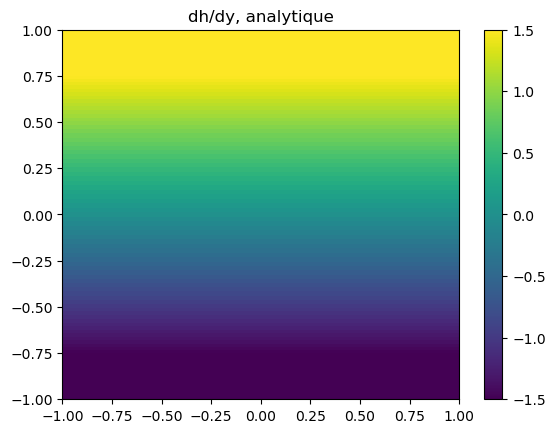

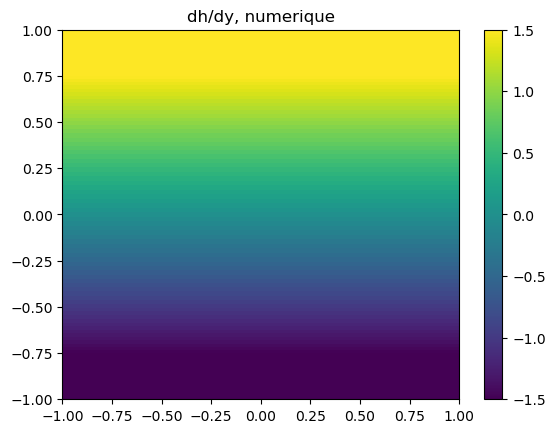

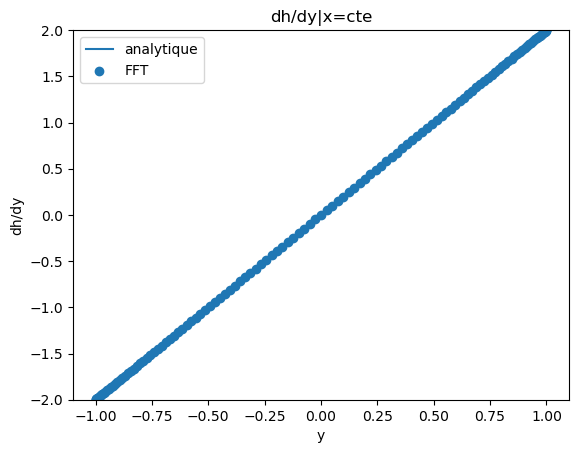

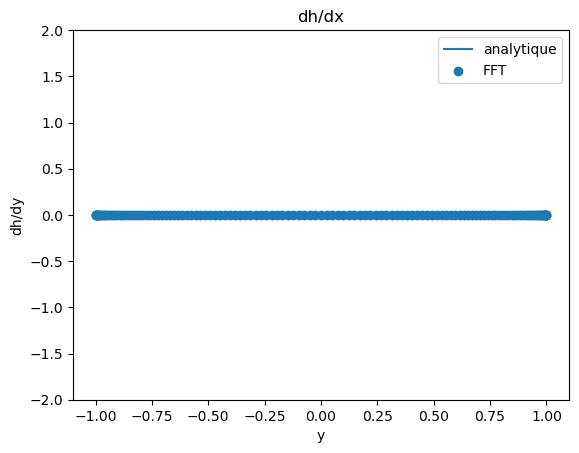

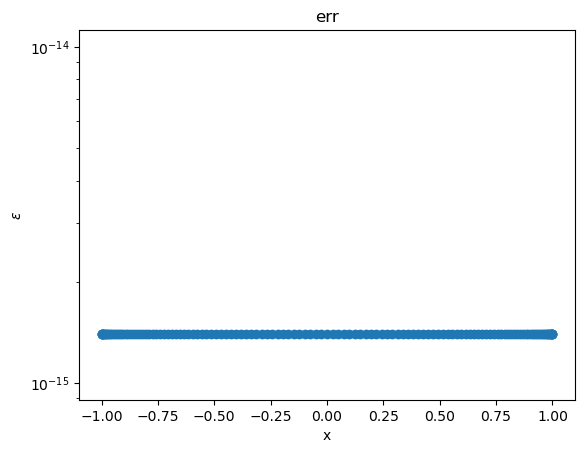

In [17]:
#h = lambda x, y : np.cosh(y)
#h_py = lambda x, y : np.sinh(y)

h = lambda x, y : y**2
h_py = lambda x, y: 2.*y
h_ppy = lambda x, y : 2.*np.ones_like(y)
#h = lambda x, y : y
#h_py = lambda x, y : 1.*np.ones(y.shape)

N=128
j = np.arange(N+1)
x = np.cos(np.pi * j / N)

Y, X = np.meshgrid(x, x, indexing = 'ij')


dh_dy = Cheb_FFT_2D(h(X, Y), axis = 'y')
dh_dx = Cheb_FFT_2D(h(X, Y), axis = 'x')


fig = plt.figure()

ax=plt.axes()
ax.set_title("dh/dy, analytique")
cf = ax.pcolormesh(X, Y, h_py(X,Y), vmin = -1.5, vmax =1.5)
fig.colorbar(cf, ax=ax)


fig = plt.figure()
ax=plt.axes()
ax.set_title("dh/dy, numerique")
cf = ax.pcolormesh(X, Y, dh_dy, vmin = -1.5, vmax =1.5)
fig.colorbar(cf, ax=ax)

fig  = plt.figure()
plt.title("dh/dy|x=cte")
plt.plot(x, h_py(X, Y)[:, N//2], label = 'analytique')
plt.scatter(x, dh_dy[:, N//2], label = 'FFT')
plt.legend()
plt.xlabel('y')
plt.ylabel("dh/dy")
plt.ylim(-2., 2.)

fig  = plt.figure()
plt.title("dh/dx")
plt.plot(x, np.zeros_like(dh_dx[:, N//2]), label = 'analytique')
plt.scatter(x, dh_dx[:, N//2], label = 'FFT')
plt.legend()
plt.xlabel('y')
plt.ylabel("dh/dy")
plt.ylim(-2., 2.)


fig = plt.figure()
plt.title('err')
err = np.abs(h_py(X, Y)[N//2, :]-dh_dy[N//2, :])
plt.scatter(x, err)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

## Dérivation par FFT

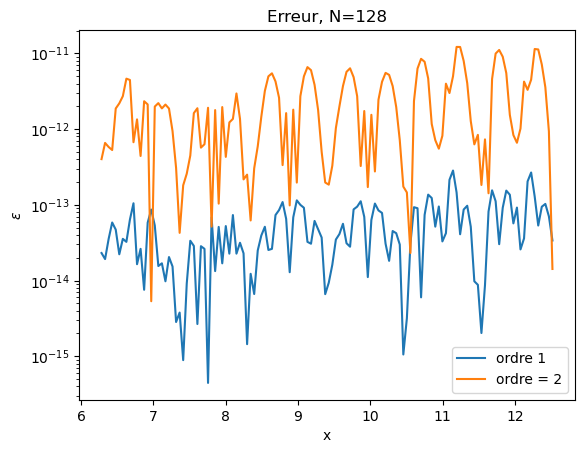

In [18]:
def Fourier_deriv(y, a = 0., b = 2.0*np.pi, real = True, order = 1):
    "calcul de la dérivée d'ordre n (paramètre order) d'une fonction périodique 1D définie sur l'intervalle [a, b]"
    k = 2.0*np.pi * scipy.fft.fftfreq(y.size, d=((b-a)/y.size))
    y_hat = scipy.fft.fft(y)
    
    y_hat_p = (1.j*k)**order * y_hat
    y_p = scipy.fft.ifft(y_hat_p)
    if real : 
        y_p = y_p.real
    return 2.0*np.pi/(b-a)*y_p
Nx = 128

X = np.linspace(2.0*np.pi, 4.0*np.pi,Nx, endpoint= False)

f_x= np.cos(3.*X)
fp_x = -3.*np.sin(3.*X)
fpp_x = -9.0*np.cos(3.0*X)

Df_dx = Fourier_deriv(f_x,a=2.*np.pi, b=4.*np.pi)
D2f_dx = Fourier_deriv(f_x,a=2.*np.pi, b=4.*np.pi, order =2)
#print(Df_dx)


err_Fourier = np.abs(Df_dx -fp_x)
err_f2 = np.abs(D2f_dx - fpp_x)


fig = plt.figure()
plt.title(f"Erreur, N={Nx}")
plt.plot(X, err_Fourier, label = "ordre 1")
plt.plot(X, err_f2, label = "ordre = 2")
plt.xlabel('x')
plt.ylabel(r'$\epsilon$')
plt.yscale('log')
plt.legend()


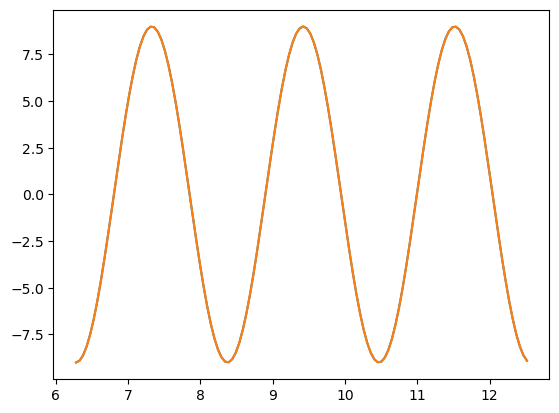

In [19]:
fig = plt.figure()
plt.plot(X, D2f_dx, label = 'numerique')
plt.plot(X, fpp_x, label = 'analytique')

# Intégration par collocation, Fourier

## 1) Chebyshev
On utilise la méthode de Clenshaw-Curtis

In [80]:
import numba

Text(0.5, 1.0, '$f(x) =x^{10}$')

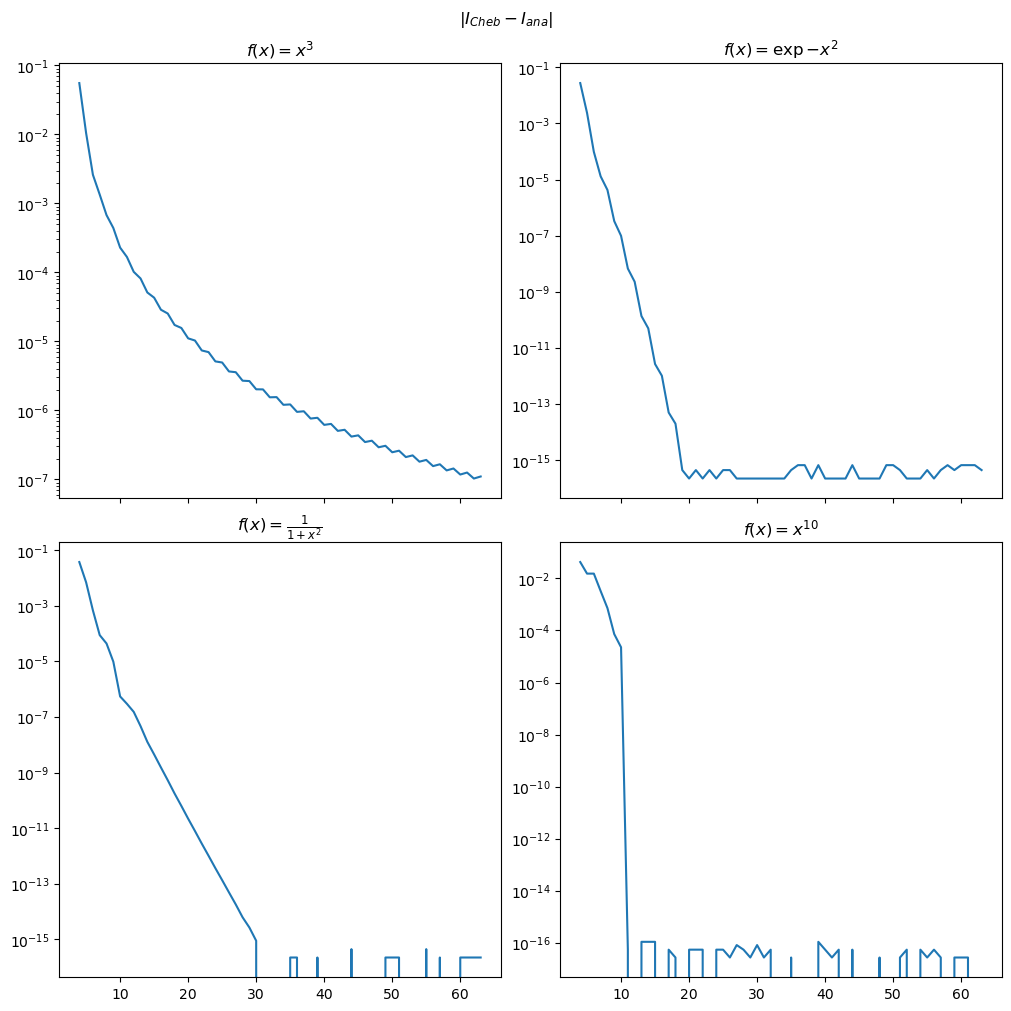

In [96]:
#M"thode de Clenshaw-Curtis

@numba.njit
def Clenshaw_Curtis_weight(N):
    #print("Appel Clenshaw_Curtis_weights")
    N -=1#définit le degré des polynomes
    theta = np.pi*np.arange(0, N+1)/N
    #print(f"theta = {theta}")
    
    w = np.zeros(N+1)
    #print(f"w = {w}")
    ii = np.arange(1, N)
    #print(f"ii = {ii}")
    v = np.ones(N-1)
    #print(f"v = {v}")
    #print(f"theta[ii] {theta[ii]}")
    if ( N % 2 ) == 0 : 
        #print(f"N+1 pair")
        w[0] = 1.0/ ( N**2 - 1.0 )
        w[-1] = w[0]
        #print(f"w = {w}")
        for k in np.arange(1, N/2):
            v = v-2.0*np.cos(2.0*k*theta[ii])/( 4.0* ( k**2 ) -1 )
        #print(f"Après boucle : v={v}")
        v = v - np.cos(N*theta[ii])/(N**2-1.0)
        #print(f"v = {v}")
    else:
        #print(f"N+1 impair")
        w[0] = 1.0/N**2
        w[-1] = w[0]
        for k in np.arange(1, (N-1)/2+1):
            v = v - 2.0*np.cos(2.0*k*theta[ii])/( 4.0 * ( k**2 ) - 1.0 )
    #print(f"v = {v}")
    w[ii] = 2.0*v/N
    return w

#@numba.jit
def Cheb_quad(y, a=-1.0, b = 1.0) :
    "S'applique UNIQUEMENT A UN TABLEAU 1D"
    weights = ((b -a )/2.0)*Clenshaw_Curtis_weight(y.size)
    #weights = clencurt(y.size-1)
    #return np.sum(weights * y, axis = axis)
    return np.dot(weights, y)
a = -1.0
b = 1.0
#n = np.arange(4, 513, 5)
n=np.arange(4, 64 ,1)
#w = Clenshaw_Curtis_weight(n, a= 0.0, b = 1.0)

#print(f"x = {x}")
f_pol = lambda x: np.abs(x**3)
I_pol_exact = 0.5

err_pol = np.zeros(n.size)

f_gauss = lambda x: np.exp(-x**2)
#I_gauss_exact = 2.0 * ( np.exp(-1.0) + np.sqrt(np.pi)* ( scipy.special.erf( 1.0 ) - 1.0 ) )
I_gauss_exact = np.sqrt(np.pi) * scipy.special.erf(1.0)


err_gauss = np.zeros(n.size)

f_sm = lambda x : 1.0/(1.0+x**2)
I_sm_exact = np.pi/2.0
err_sm = np.zeros(n.size)

f_pol10 = lambda x : x**10
I_pol10_exact = 2.0/11.0
err_pol10 = np.zeros(n.size)


for i in range(0, n.size):
    x_i = collocation_points(n[i])
    err_pol[i] = np.abs(Cheb_quad(f_pol(x_i) ) - I_pol_exact)
    err_gauss[i] = np.abs(Cheb_quad(f_gauss(x_i) ) - I_gauss_exact)
    err_sm[i] = np.abs(Cheb_quad(f_sm(x_i) ) - I_sm_exact)
    err_pol10[i] = np.abs(Cheb_quad(f_pol10(x_i) ) - I_pol10_exact)


fig = plt.figure( figsize  = (10, 10), constrained_layout = True)
axs = fig.subplots(2, 2, squeeze = False, sharex = True, sharey = False)
fig.suptitle(r'$|I_{Cheb} - I_{ana}|$')
axs[0, 0].plot(n, err_pol)
axs[0, 0].set_yscale('log')
axs[0, 0].set_title(r'$f(x) = x^3$')

axs[0, 1].plot(n, err_gauss)
axs[0, 1].set_yscale('log')
axs[0, 1].set_title(r'$f(x) = \exp{-x^2}$')

axs[1, 0].plot(n, err_sm)
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r'$f(x) = \frac{1}{1+x^2}$')

axs[1, 1].plot(n, err_pol10)
axs[1, 1].set_yscale('log')
axs[1, 1].set_title(r'$f(x) =x^{10}$')
# Adding main title
# Adjusting the layout for better view


In [97]:
x_C = collocation_points(128)
y_C=np.exp(x_C)
%timeit Cheb_quad(y_C)

95.1 μs ± 2.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [23]:
import numpy.polynomial.chebyshev as npcheb


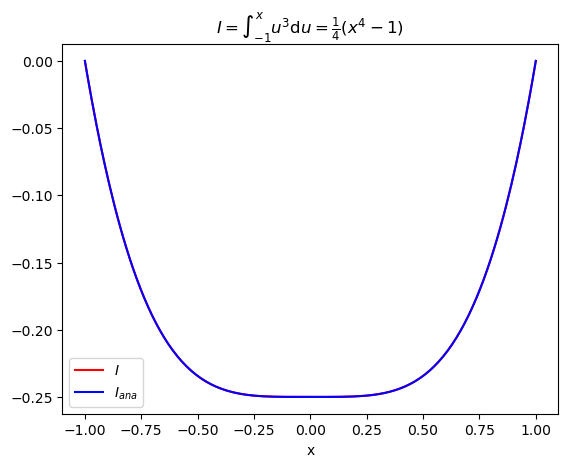

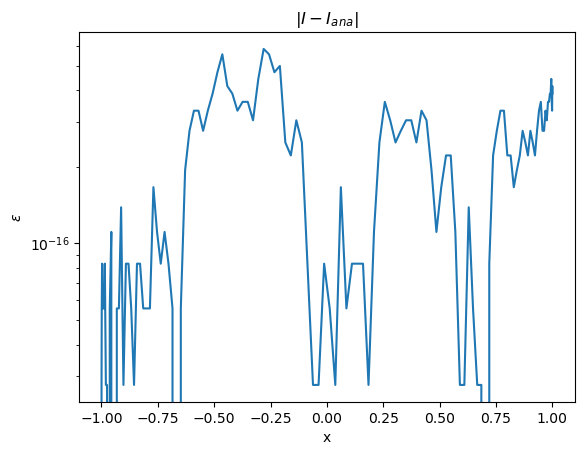

In [24]:
def Cheb_cumsum(y, x) :
    "Idem que Chebquad, mais pour une intégrale cumulée"
    coeffs = npcheb.chebfit(x, y, len(y)-1)
    coeffs_int = npcheb.chebint(coeffs)
    y_int = npcheb.chebval(x, coeffs_int)
    return y_int-y_int[-1]

f_pol = lambda xx: xx**3
x = collocation_points(128)

f_pol_int = lambda xx: (xx**4)

I = Cheb_cumsum(f_pol(x), x)
I_ana = (f_pol_int(x)-1.0)/4.0
fig = plt.figure()
plt.title(r"$I = \int_{-1}^x u^3 \mathrm{d}u=\frac{1}{4}(x^4-1)$")
plt.plot(x, I, color = 'r', label =r"$I$")
plt.plot(x, I_ana, color = 'b', label =r"$I_{ana}$")
plt.xlabel("x")
plt.legend()

err = np.abs(I -I_ana)
fig = plt.figure()
plt.title(r"$|I-I_{ana}|$")
plt.plot(x, err)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

In [25]:
import sympy as sp
import IPython.display as ipd
sp.init_printing(use_latex=True)

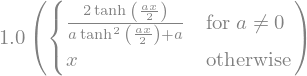

In [26]:
X, Y, a = sp.symbols('x y a')
I_sech = sp.integrate(1.0/(sp.cosh(a*X)**2), X)
ipd.display(I_sech)

I_sech_ana = sp.utilities.lambdify((X, a), I_sech)

[3.99963682e-01 3.99963626e-01 3.99963458e-01 3.99963175e-01
 3.99962771e-01 3.99962240e-01 3.99961571e-01 3.99960753e-01
 3.99959768e-01 3.99958599e-01 3.99957221e-01 3.99955606e-01
 3.99953720e-01 3.99951522e-01 3.99948961e-01 3.99945979e-01
 3.99942502e-01 3.99938444e-01 3.99933700e-01 3.99928141e-01
 3.99921613e-01 3.99913926e-01 3.99904851e-01 3.99894105e-01
 3.99881344e-01 3.99866141e-01 3.99847974e-01 3.99826196e-01
 3.99800005e-01 3.99768408e-01 3.99730166e-01 3.99683737e-01
 3.99627192e-01 3.99558116e-01 3.99473481e-01 3.99369477e-01
 3.99241310e-01 3.99082932e-01 3.98886708e-01 3.98642986e-01
 3.98339556e-01 3.97960961e-01 3.97487634e-01 3.96894811e-01
 3.96151183e-01 3.95217223e-01 3.94043162e-01 3.92566553e-01
 3.90709442e-01 3.88375181e-01 3.85445043e-01 3.81774969e-01
 3.77193022e-01 3.71498472e-01 3.64463914e-01 3.55842260e-01
 3.45380761e-01 3.32844098e-01 3.18047445e-01 3.00897995e-01
 2.81439514e-01 2.59889956e-01 2.36659092e-01 2.12334258e-01
 1.87629424e-01 1.633045

Text(0, 0.5, '$\\epsilon$')

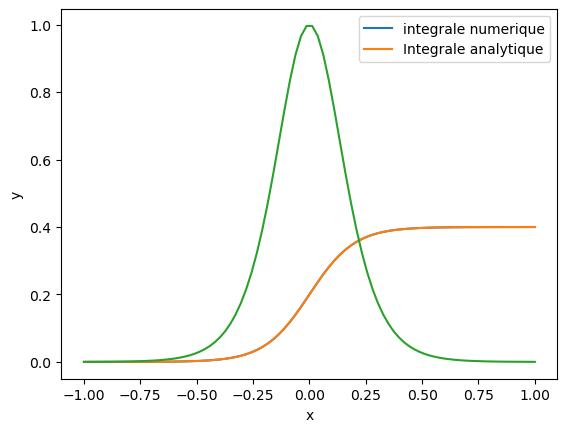

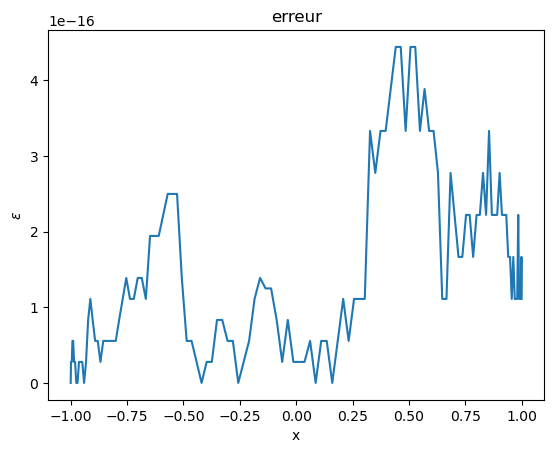

In [27]:
y = 1.0/(np.cosh(5.0*x)**2)
I_bickley = Cheb_cumsum(y, x)
I_bickley_ana = I_sech_ana(x, 5.0)-I_sech_ana(-1.0, 5.0)

print(I_bickley)
fig = plt.figure()
plt.plot(x, I_bickley, label = 'integrale numerique')
plt.plot(x, I_bickley_ana, label = 'Integrale analytique')
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

fig = plt.figure()
plt.title("erreur")
plt.plot(x, np.abs(I_bickley - I_bickley_ana))
plt.xlabel('x')
plt.ylabel(r'$\epsilon$')

## Fourier

[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 4.4408921e-16]


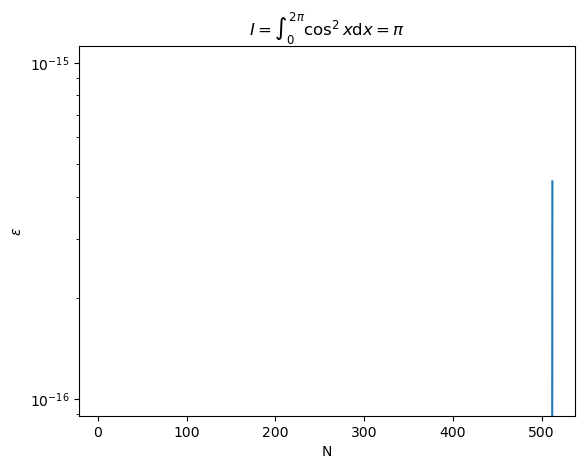

In [28]:

f = lambda X:np.cos(X)**2
#I_x = scipy.integrate.trapz(f_x, x=x)
I_ana = np.pi

liste_N = [4, 8, 16, 32, 64, 128, 256, 512]
err = np.zeros(len(liste_N))

def Fourier_quad(y, dx):
    return np.sum(y)*dx

for i in range(0, len(liste_N)):
    x_i = np.linspace(0.0, 2.0*np.pi, liste_N[i], endpoint = False)
    dx_i = x_i[1] - x_i[0]
    I_i = Fourier_quad(f(x_i), dx_i)
    err[i] = np.abs(I_i - I_ana)
print(err)
fig = plt.figure()
plt.title(r"$I = \int_0^{2\pi} \cos^2x \mathrm{d}x = \pi$")
plt.plot(liste_N, err)
plt.xlabel('N')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

### Pareil, mais pour $\int_a^x f(x')\mathrm{d}x'$

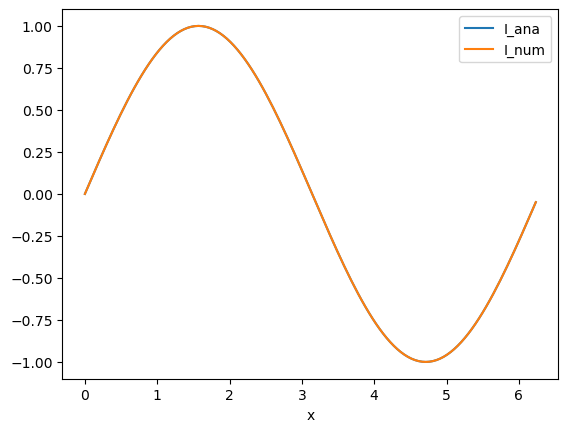

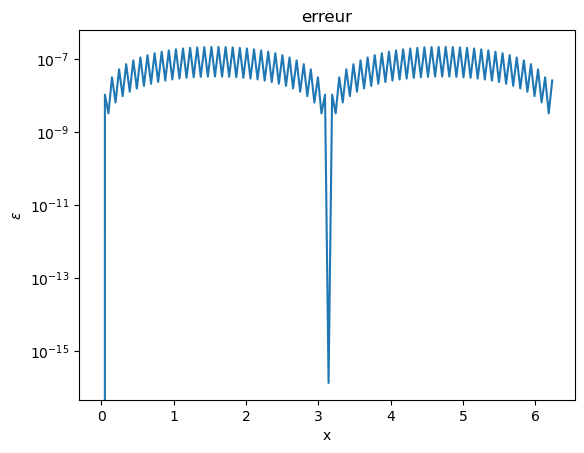

In [74]:
def Fourier_cumsum(y, dx):
    I = scipy.integrate.cumulative_simpson(y, dx=dx, initial=0.0)
    return I

N_f=  128

x_f = np.linspace(0.0, 2.0*np.pi, N_f, endpoint = False)
dx_f = x_f[1]-x_f[0]
f_x = np.cos(x_f)

I_f_ana = np.sin(x_f)
#I_f_ana = x_f/2.0 + np.sin(2.0*x_f)/4.0

I_f_num = Fourier_cumsum(f_x, dx_f)

fig = plt.figure()
plt.plot(x_f, I_f_ana, label = 'I_ana')
plt.plot(x_f, I_f_num, label = 'I_num')
plt.xlabel('x')
plt.legend()

err_f = np.abs(I_f_ana-I_f_num)

fig= plt.figure()
plt.title('erreur')
plt.plot(x_f, err_f)
plt.xlabel('x')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')

In [75]:
I_f_num

array([ 0.00000000e+00,  4.90676640e-02,  9.80171435e-02,  1.46730444e-01,
        1.95090328e-01,  2.42980129e-01,  2.90284687e-01,  3.36889783e-01,
        3.82683445e-01,  4.27555004e-01,  4.71396752e-01,  5.14102636e-01,
        5.55570251e-01,  5.95699180e-01,  6.34393305e-01,  6.71558814e-01,
        7.07106804e-01,  7.40950970e-01,  7.73010478e-01,  8.03207363e-01,
        8.31469639e-01,  8.57728430e-01,  8.81921293e-01,  9.03989104e-01,
        9.23879562e-01,  9.41543868e-01,  9.56940367e-01,  9.70031050e-01,
        9.80785312e-01,  9.89176303e-01,  9.95184759e-01,  9.98795247e-01,
        1.00000003e+00,  9.98795247e-01,  9.95184759e-01,  9.89176303e-01,
        9.80785312e-01,  9.70031050e-01,  9.56940367e-01,  9.41543868e-01,
        9.23879562e-01,  9.03989104e-01,  8.81921293e-01,  8.57728430e-01,
        8.31469639e-01,  8.03207363e-01,  7.73010478e-01,  7.40950970e-01,
        7.07106804e-01,  6.71558814e-01,  6.34393305e-01,  5.95699180e-01,
        5.55570251e-01,  

In [76]:
%timeit Fourier_cumsum(f_x, dx_f)

57.8 μs ± 453 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Intégrale double


On veut calculer 
$$
I = \int_0^{2\pi}\int_{-1}^1 \cos^2 x \cosh y \mathrm{d}x\mathrm{d}y = 2\pi \sinh(1)
$$

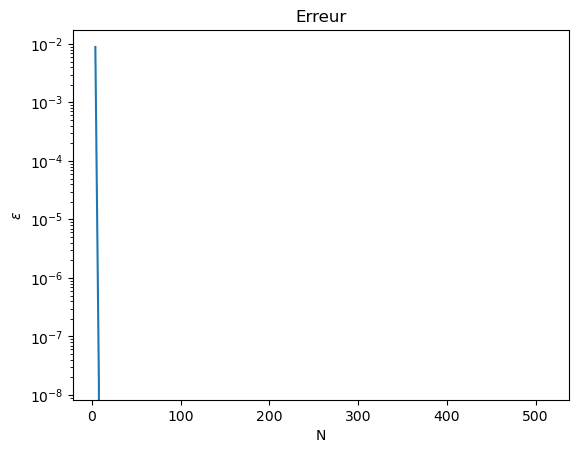

In [33]:

I_ana = 2.0*np.pi*np.sinh(1.0)

liste_N = [4, 8, 16, 32, 64, 128, 256, 512]
#liste_N = [8]
liste_err = np.zeros(len(liste_N))

f = lambda x, y : ( np.cos(x)**2 ) *np.cosh(y)



for i in range(0, len(liste_N)):
    x_i = np.linspace(0.0, 2.0*np.pi, liste_N[i], endpoint = False)
    y_i = collocation_points( liste_N[i] )
    X_i, Y_i = np.meshgrid(x_i, y_i, indexing = 'ij')
    f_i = f(X_i, Y_i)
    dx_i = x_i[1] - x_i[0]
    I_y = np.apply_along_axis(Cheb_quad, 1, f_i)
    #print(f"I_y = {I_y}")
    #print(f"2sinh(1)*cos(x)**2 {2.0*np.sinh(1.0)* (np.cos(x_i)**2)}")
    I_i = np.apply_along_axis(Fourier_quad, 0, I_y, dx_i)
    liste_err[i] = np.abs(I_i - I_ana)
#"""
fig = plt.figure()
plt.title(r"Erreur")
plt.plot(liste_N, liste_err)
plt.xlabel('N')
plt.ylabel(r"$\epsilon$")
plt.yscale('log')
#"""

In [34]:
liste_err

array([8.88190121e-03, 1.60922689e-08, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

# Divers

In [30]:
np.__version__

'1.26.4'

In [31]:
scipy.__version__

'1.16.2'

In [89]:
mpl.__version__

'3.8.0'